# Văn phòng — toà nhà văn phòng, trụ sở doanh nghiệp

Nối tiếp `eda_hanhchinh.ipynb`. Đầu vào: `poi_extended_7tinh_con_lai_sau_hanhchinh.parquet`.
**Đây là lớp THỨ CHÍN và là lớp CUỐI của chuỗi.** (Tám lớp trước: nhà ở · lưu trú · thương
mại · giải trí · tham quan · trường học · y tế · hành chính — đúng danh sách mà cell kiểm
"không đếm đôi" ở cuối notebook duyệt qua.)

## Lớp này khác tám lớp trước ở chỗ căn bản: nó được định nghĩa bằng PHỦ ĐỊNH

Tám lớp trước đều có một tín hiệu DƯƠNG để bám: `tourism=hotel`, `shop=mall`,
`amenity=school`, `office=government`. Lớp văn phòng gần như không có — OSM không có tag
nào nghĩa là "toà nhà văn phòng". `building=office` chỉ phủ một phần nhỏ, `office=*` mô tả
một *doanh nghiệp thuê chỗ* chứ không mô tả *toà nhà*.

Nên định nghĩa thực tế của lớp này là: **một công trình đủ lớn, KHÔNG thuộc tám lớp trước,
và có dấu hiệu hoạt động kinh tế.** Đó là một định nghĩa yếu, và phải nói thẳng ngay từ
đầu — mọi con số của lớp này kém tin hơn tám lớp trên.

Đổi lại, lớp cuối được hưởng một thứ không lớp nào có: **tám lớp trước đã dọn sạch mọi thứ
dễ nhầm**. Bãi đỗ, trường học, bệnh viện, cơ quan nhà nước, TTTM, khách sạn — tất cả đã
ra khỏi bộ. Cái còn lại đủ lớn mà vẫn vô danh thì khả năng là văn phòng cao hơn hẳn so với
nếu chạy lớp này đầu tiên.

## Hai món nợ được bàn giao tới đây

- **`poi_morph_review_7tinh.parquet`** — 104 toà ≥ 8 tầng mà `eda_chungcu` không tách được
  là chung cư hay văn phòng, đã treo từ lớp đầu tiên; **38** trong số đó còn nằm trong bộ
  vào của lớp này.
- **`landuse=commercial`** (**1.241** dòng, số đo ở cell kế) — lớp thương mại CỐ Ý không
  nhận vì đó là ô đất dịch vụ–văn phòng chứ không phải điểm bán lẻ.

> ⚠ Mọi con số viết tay trong notebook này đều là số của **vòng chạy ngày 2026-08-09** trên
> bộ vào **143.833** dòng. Bộ vào đổi khi bất kỳ lớp nào ở thượng nguồn chạy lại; cell
> **SỐ CHỐT** ở cuối in ra đúng những con số mà phần kết luận trích dẫn, để đối chiếu.

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

EDA_DIR = ROOT / "data/qa/eda"
SCOPE = "7tinh"
LOP = "vanphong"
LOP_TRUOC = "hanhchinh"

poi = pq.read_table(EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP_TRUOC}.parquet").to_pandas()


def parse_tags(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return {}
    return {}


poi["tags_dict"] = poi["tags"].map(parse_tags)
td = poi["tags_dict"]


def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFD", str(s)).replace("đ", "d").replace("Đ", "D")
    return re.sub(r"[̀-ͯ]", "", s).lower()


def tag(key):
    return td.map(lambda t, k=key: str(t[k]).lower() if k in t else None)


for k in [
    "office",
    "building",
    "landuse",
    "amenity",
    "shop",
    "leisure",
    "tourism",
    "healthcare",
    "historic",
    "man_made",
    "highway",
    "public_transport",
    "railway",
    "aeroway",
    "craft",
    "place",
    "military",
    "religion",
    "government",
    "boundary",
    "power",
    "industrial",
]:
    poi[k] = tag(k)
poi["levels"] = pd.to_numeric(td.map(lambda t: t.get("building:levels")), errors="coerce")
poi["operator"] = td.map(lambda t: t.get("operator"))
poi["brand"] = td.map(lambda t: t.get("brand"))

# Chỉ nạp các trường là TÊN CỦA CHÍNH VẬT THỂ. `official_name` / `short_name` thuộc nhóm
# này và trước đây bị bỏ quên — cổng độc lập đo được 2 dòng lọt lưới vì thế ("Minh Tâm
# Prolab" có `official_name` = "Công ty ..."). CỐ Ý KHÔNG nạp `operator` / `brand` /
# `addr:housename` / `description`: chúng mô tả NGƯỜI VẬN HÀNH hoặc VẬT CHỨA, không mô tả
# vật thể — nạp vào sẽ kéo 305 cây xăng "CTXD Quân đội" và cửa hàng trong toà nhà vào lớp.
TEN_CUA_CHINH_NO = ("name:vi", "name:en", "alt_name", "old_name", "official_name", "short_name")
alt_names = td.map(lambda t: " ".join(v for v in (t.get(k) for k in TEN_CUA_CHINH_NO) if v))
poi["name_norm"] = (
    poi["name"].fillna("").map(strip_accents) + " " + alt_names.map(strip_accents)
).str.strip()
name_norm = poi["name_norm"]

print(
    f"bộ vào: {len(poi):,} dòng | polygon {poi['is_area'].mean():.0%} | có tên {poi['name'].notna().mean():.0%}"
)
print(
    f"→ bộ gốc ban đầu là 193.509 dòng; bảy lớp trước đã bóc đi"
    f" {193509 - len(poi):,} ({(193509 - len(poi)) / 193509:.0%})"
)

bộ vào: 143,827 dòng | polygon 31% | có tên 42%
→ bộ gốc ban đầu là 193.509 dòng; bảy lớp trước đã bóc đi 49,682 (26%)


## Chân dung hình thái — và cái giá của việc chạy CUỐI

In [2]:
_uv = poi[
    poi["office"].notna()
    | poi["building"].isin(["office", "commercial"])
    | poi["landuse"].eq("commercial")
    | name_norm.str.contains(r"toa nha|\btower\b|van phong|\bcao oc\b", na=False)
]
print(
    f"ứng viên thô: {len(_uv):,} | polygon {_uv['is_area'].mean():.0%}"
    f" | có tên {_uv['name'].notna().mean():.0%} | n_tags trung vị {_uv['n_tags'].median():.0f}"
)

print("\n── 1. `building:levels` — cột duy nhất lớp này giàu hơn mọi lớp khác ──")
print(f"  toàn bộ bộ vào : {poi['levels'].notna().sum():,} ({poi['levels'].notna().mean():.1%})")
print(f"  trong ứng viên : {_uv['levels'].notna().sum():,} ({_uv['levels'].notna().mean():.1%})")
print(
    f"  phân phối số tầng (ứng viên): {_uv['levels'].describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_dict()}"
)

print("\n── 2. `office=*` mô tả DOANH NGHIỆP, không mô tả TOÀ NHÀ ──")
print("  ", poi["office"].value_counts().head(10).to_dict())
_toa = name_norm.str.contains(r"toa nha|\btower\b|\bcao oc\b|\bbuilding\b", na=False)
print(
    f"  tên nói 'toà nhà / tower / cao ốc': {int(_toa.sum()):,}"
    f" — trong đó có `office=*`: {int((_toa & poi['office'].notna()).sum()):,}"
    f" ({(_toa & poi['office'].notna()).sum() / max(_toa.sum(), 1):.0%})"
)
print(
    "  → hai khái niệm này gần như KHÔNG chồng nhau. Một toà nhà văn phòng thường được map"
    " thành polygon `building=*` không tag `office`; còn `office=company` thường là node"
)
print("    của một công ty thuê chỗ bên trong. Đây là lý do lớp này phải dùng HÌNH THÁI.")

print("\n── 3. các họ tag ứng viên ──")
for k in ["office", "building", "landuse", "amenity"]:
    v = poi[k].value_counts()
    print(f"  {k:10s} {v.sum():6,} → {v.head(8).to_dict()}")

ứng viên thô: 3,778 | polygon 68% | có tên 61% | n_tags trung vị 3

── 1. `building:levels` — cột duy nhất lớp này giàu hơn mọi lớp khác ──
  toàn bộ bộ vào : 982 (0.7%)
  trong ứng viên : 309 (8.2%)
  phân phối số tầng (ứng viên): {'count': 309.0, 'mean': 10.4, 'std': 8.3, 'min': 0.0, '50%': 8.0, '90%': 22.2, '99%': 36.8, 'max': 45.0}

── 2. `office=*` mô tả DOANH NGHIỆP, không mô tả TOÀ NHÀ ──
   {'company': 806, 'yes': 215, 'telecommunication': 69, 'estate_agent': 50, 'newspaper': 41, 'lawyer': 36, 'travel_agent': 35, 'it': 31, 'insurance': 26, 'association': 24}
  tên nói 'toà nhà / tower / cao ốc': 357 — trong đó có `office=*`: 34 (10%)
  → hai khái niệm này gần như KHÔNG chồng nhau. Một toà nhà văn phòng thường được map thành polygon `building=*` không tag `office`; còn `office=company` thường là node
    của một công ty thuê chỗ bên trong. Đây là lý do lớp này phải dùng HÌNH THÁI.

── 3. các họ tag ứng viên ──
  office      1,563 → {'company': 806, 'yes': 215, 'telecommunication

### Chọn trục

1. **CHIỀU CAO (`building:levels`)** — trục chính, và là lần DUY NHẤT trong chuỗi nó dùng
   được. Một công trình ≥ 8 tầng, không mang tag chức năng nào khác, sau khi tám lớp trước
   đã dọn sạch, thì gần như chỉ còn là toà văn phòng hoặc chung cư.
2. **`office=*` — NGÀNH NGHỀ, không phải loại công trình.** Dùng để phân nhóm, không dùng
   để xác định "đây có phải toà văn phòng không". Hệ quả đã đo ở LUẬT 4: `office=company`
   trên một polygon `landuse=industrial` KHÔNG cứu được nó khỏi nhãn nhà máy.
3. **HÌNH THÁI + PHỦ ĐỊNH** — công trình lớn, không tag chức năng, không thuộc tám lớp
   trước. Trục yếu nhất về mặt logic nhưng phủ rộng nhất.

**Trục bị loại có lý do:** *thừa kế thương hiệu* (lớp thương mại) — văn phòng không có
chuỗi; *đối chứng chéo hai nguồn* (lớp trường học / y tế) — OSM chỉ có MỘT hệ tag cho văn
phòng, không có gì để đối chứng; *thước ngoài* (lớp hành chính) — không ai biết có bao
nhiêu toà văn phòng ở Hà Nội.

## Bước 1 — filter MỎNG, ưu tiên recall

In [3]:
# --- A. tag văn phòng / thương mại ---
VP_TAG = (
    poi["office"].notna()
    | poi["building"].isin(["office", "commercial"])
    | poi["landuse"].eq("commercial")
)
# --- B. tên ---
# `\btoa\b` trần khớp "Toà án" (đã bóc ở lớp hành chính) và "Toạ"; `\bthap\b` khớp "Tháp"
# (tháp nước, tháp truyền hình). Cả hai chỉ dùng kèm ngữ cảnh.
VP_RX = (
    r"toa nha|\bcao oc\b|\btower\b|\btrung tam thuong mai va van phong\b"
    r"|van phong|\boffice\b|\bbuilding\b|\bcomplex\b|\bcenter\b|\bcentre\b"
    r"|tru so (?:cong ty|chinh|lam viec)|cong ty|\bcty\b|\btnhh\b|\bcp \b|tap doan|tong cong ty"
    r"|chi nhanh|van phong dai dien|\bvpdd\b|coworking|\bstartup\b"
)
VP_NAME = name_norm.str.contains(VP_RX, regex=True, na=False)
# --- C. HÌNH THÁI: công trình cao, không tag chức năng ---
# Nhánh riêng của lớp cuối. `FUNC_KEYS` giống hệt danh sách của `eda_chungcu` — cố ý, vì
# nhóm này chính là món nợ mà lớp đó treo lại.
FUNC_KEYS = {
    "amenity",
    "shop",
    "office",
    "tourism",
    "leisure",
    "man_made",
    "historic",
    "highway",
    "public_transport",
    "railway",
    "power",
    "natural",
    "craft",
    "healthcare",
    "military",
    "government",
}
# KHÁC `eda_chungcu` một điểm, và đây là quyết định có chủ ý: lớp đó đòi KHÔNG có tag chức
# năng nào; lớp này KHÔNG đòi. Lý do: một toà 15 tầng có chi nhánh ngân hàng ở tầng trệt vẫn
# là một toà văn phòng — tầng trệt là đơn vị THUÊ, không phải bản chất toà nhà. Số đo in ra
# ngay dưới đây cho biết nhóm này lớn cỡ nào; LUẬT 3 sẽ cắm cờ `mixed_use` cho chúng thay
# vì xoá (số dòng thực sự được cắm cờ in ở cell LUẬT 3).
VP_HINH_THAI = poi["building"].notna() & poi["levels"].ge(8) & poi["is_area"]
_chat = ~td.map(lambda t: bool(FUNC_KEYS & t.keys()))
print(f"hình thái ≥8 tầng: {int(VP_HINH_THAI.sum()):,}"
      f" — trong đó {int((VP_HINH_THAI & ~_chat).sum()):,} có kèm tag chức năng khác"
      " (tầng đế cho thuê) ⇒ vẫn tuyển, cắm cờ mixed_use ở bước 3")
# --- D. món nợ bàn giao từ lớp nhà ở ---
MORPH_PATH = EDA_DIR / f"poi_morph_review_{SCOPE}.parquet"
if MORPH_PATH.exists():
    morph_uids = set(pq.read_table(MORPH_PATH, columns=["uid"]).to_pandas()["uid"])
    VP_MORPH = poi["uid"].isin(morph_uids)
    print(
        f"nhận bàn giao từ `eda_chungcu`: {len(morph_uids)} uid trong {MORPH_PATH.name},"
        f" còn lại trong bộ này: {int(VP_MORPH.sum())}"
    )
else:
    VP_MORPH = pd.Series(False, index=poi.index)
    print(f"⚠ không tìm thấy {MORPH_PATH.name} — nhánh D rỗng")

poi["is_vp"] = VP_TAG | VP_NAME | VP_HINH_THAI | VP_MORPH

BR = {
    "A tag văn phòng/TM": VP_TAG,
    "B tên": VP_NAME,
    "C hình thái ≥8 tầng": VP_HINH_THAI,
    "D nợ từ lớp nhà ở": VP_MORPH,
}
print()
for ten, m in BR.items():
    print(f"  {ten:24s} {m.sum():6,}")
print(f"  {'HỢP':24s} {poi['is_vp'].sum():6,} / {len(poi):,} ({poi['is_vp'].mean():.2%})")
print("\nđóng góp RIÊNG của từng nhánh:")
for ten, m in BR.items():
    khac = np.logical_or.reduce([v.values for k, v in BR.items() if k != ten])
    chi_no = m & ~khac
    print(f"  {ten:24s} {chi_no.sum():5,}  {poi.loc[chi_no, 'name'].dropna().head(3).tolist()}")

hình thái ≥8 tầng: 194 — trong đó 56 có kèm tag chức năng khác (tầng đế cho thuê) ⇒ vẫn tuyển, cắm cờ mixed_use ở bước 3
nhận bàn giao từ `eda_chungcu`: 104 uid trong poi_morph_review_7tinh.parquet, còn lại trong bộ này: 38

  A tag văn phòng/TM        3,589
  B tên                     2,487
  C hình thái ≥8 tầng         194
  D nợ từ lớp nhà ở            38
  HỢP                       5,115 / 143,827 (3.56%)

đóng góp RIÊNG của từng nhánh:
  A tag văn phòng/TM       2,556  ['Đại Lý Bảo Hiểm Prudential', 'TCI Buiding', 'Oxfam']
  B tên                    1,492  ['Tòa nhà King Palace - 108 Nguyễn Trãi', 'CongTy TNHH Hong Ly', '196 Giải Phóng - Ngân hàng Nông nghiệp & PTNT Chi nhánh Nam Hà Nội']
  C hình thái ≥8 tầng         28  ['Shang Garden', 'The Adora Permium', 'VietinBank']
  D nợ từ lớp nhà ở            0  []


### Cổng recall 1 — phủ tag chắc chắn

In [4]:
CHECKS = {
    "office=* (mọi giá trị)": poi["office"].notna(),
    "building=office": poi["building"].eq("office"),
    "building=commercial": poi["building"].eq("commercial"),
    "landuse=commercial": poi["landuse"].eq("commercial"),
    "tên 'toà nhà'": name_norm.str.contains(r"toa nha", na=False),
    "tên 'tower'": name_norm.str.contains(r"\btower\b", na=False),
    "tên 'văn phòng'": name_norm.str.contains(r"van phong", na=False),
    "tên 'công ty'": name_norm.str.contains(r"cong ty|\bcty\b", na=False),
    "hình thái ≥8 tầng (KHÔNG đòi vắng tag chức năng)": VP_HINH_THAI,
}
# ⚠ ĐÂY KHÔNG PHẢI BẰNG CHỨNG RECALL. Cả 9 phép thử đều là TẬP CON của điều kiện tuyển
# theo cấu tạo (`office.notna()` ⊂ VP_TAG; "toa nha"/"tower"/"van phong"/"cong ty" ⊂ VP_RX;
# phép thử cuối CHÍNH LÀ nhánh C). Vì thế "mất 0" là tất yếu và không chứng minh điều gì về
# độ phủ. Giữ lại làm CỔNG TOÀN VẸN: nếu ai đó sửa `VP_RX`/`VP_TAG` mà quên một nhánh, chỗ
# này gãy. Bằng chứng recall thật nằm ở cell sau, đo bằng các trường KHÔNG dùng để tuyển.
mat = 0
for ten, m in CHECKS.items():
    thieu = int((m & ~poi["is_vp"]).sum())
    mat += thieu
    print(f"  {ten:34s} giữ {(m & poi['is_vp']).sum():>6,}/{m.sum():<6,}  mất {thieu}")
assert mat == 0, f"toàn vẹn gãy: mất {mat} dòng"
print(f"\n✓ toàn vẹn: {len(CHECKS)}/{len(CHECKS)} phép thử khớp (tautology — xem chú thích)")

  office=* (mọi giá trị)             giữ  1,563/1,563   mất 0
  building=office                    giữ    456/456     mất 0
  building=commercial                giữ    462/462     mất 0
  landuse=commercial                 giữ  1,239/1,239   mất 0
  tên 'toà nhà'                      giữ    219/219     mất 0
  tên 'tower'                        giữ    109/109     mất 0
  tên 'văn phòng'                    giữ    126/126     mất 0
  tên 'công ty'                      giữ  1,787/1,787   mất 0
  hình thái ≥8 tầng (KHÔNG đòi vắng tag chức năng) giữ    194/194     mất 0

✓ toàn vẹn: 9/9 phép thử khớp (tautology — xem chú thích)


### Cổng recall 2 — ĐỘC LẬP THẬT

Cổng trên là tautology (mọi phép thử đều nằm trong điều kiện tuyển). Cổng này chỉ được
dùng những trường **không hề tham gia tuyển**: `building:use`, `operator`, `brand`,
`addr:housename`, và khe hẹp của nhánh C (polygon cao tầng *thiếu* tag `building`).

Mỗi đầu dò còn phải tự thu hẹp về VẬT THỂ, vì các trường này nổi tiếng mô tả nhầm chỗ:
`addr:housename` của "Techcombank" là tên TOÀ NHÀ chứa nó (đo: 11 dòng — cửa hàng bên
trong, đúng ra phải nằm ngoài lớp), `operator` của cây xăng là "CTXD Quân đội" (đo: 305
dòng). Nên mọi đầu dò cứng đều kèm `polygon` + `không mang tag chức năng nào khác` — tức
là "chính vật thể này là một công trình vô chức năng do một công ty đứng tên".

Lớp cuối còn kiêm vai trò rà soát toàn chuỗi: nếu còn một công trình lớn nào chưa thuộc
lớp nào, nó phải hiện ra ở đây.

In [5]:
_bo = poi[~poi["is_vp"]]
_ten = _bo["name_norm"]
_tags = _bo["tags_dict"]


def _f(key):
    """Giá trị một khoá TRONG BỘ BỊ BỎ, đã bỏ dấu — các khoá này KHÔNG dùng để tuyển."""
    return _tags.map(lambda t, k=key: strip_accents(t[k]) if k in t else "")


FUNC_KHAC = FUNC_KEYS | {"landuse"}
_vo_chuc_nang = _tags.map(lambda t: not (FUNC_KHAC & t.keys()))
_co_building = _tags.map(lambda t: "building" in t)
# `building` phải là giá trị TRUNG TÍNH: `building=train_station` / `church` / `school`
# là lời tự khai thuộc lớp khác, không phải công trình vô chức năng (đo: chính hai dòng
# "Ga Hà Nội", "Bến xe Mỹ Đình" — `operator` = tổng công ty, `building=train_station`).
_la_cong_trinh = (
    _bo["is_area"] & _bo["building"].isin(["yes", "office", "commercial"]) & _vo_chuc_nang
)

DAU_DO_CUNG = {
    # 1. Khe của nhánh C: nhánh C đòi `building` notna, nên polygon cao tầng KHÔNG khai
    #    `building` sẽ lọt. Đây là chỗ duy nhất điều kiện tuyển tự để hở.
    "polygon ≥ 8 tầng mà THIẾU tag `building`": _bo["levels"].ge(8)
    & _bo["is_area"]
    & ~_co_building,
    # 2. `building:use` mô tả CÔNG NĂNG TOÀ NHÀ. Chỉ tin khi vật thể chính là công trình.
    #    (`retail` cố ý không nhận: đó là lớp thương mại, không phải văn phòng.)
    "`building:use=office|commercial` trên công trình vô chức năng": _f("building:use").isin(
        ["office", "commercial"]
    )
    & _bo["is_area"]
    & _vo_chuc_nang,
    # 3. Công trình vô chức năng do một CÔNG TY đứng tên vận hành.
    "`operator`/`brand` là công ty, trên công trình vô chức năng": (
        (_f("operator") + " " + _f("brand")).str.contains(
            r"cong ty|tap doan|tong cong ty", na=False
        )
        & _la_cong_trinh
    ),
    # 4. Toà nhà tự khai tên qua `addr:housename` thay vì `name`.
    "`addr:housename` nói 'toà nhà/cao ốc/tower', trên công trình vô chức năng": _f(
        "addr:housename"
    ).str.contains(r"toa nha|\bcao oc\b|\btower\b", na=False)
    & _bo["is_area"]
    & _vo_chuc_nang,
}
DAU_DO_MEM = {
    # `building:use` mô tả TOÀ NHÀ, nhưng POI lại là một CỬA HÀNG bên trong ("Circle K",
    # "Uyên Sửa Quần Áo"). Cùng bẫy `addr:housename` của lớp lưu trú: thuộc tính của vật
    # chứa bị gắn lên vật được chứa. Phải nằm NGOÀI lớp — nên để ở đầu dò MỀM.
    "`building:use` hoặc `addr:housename` toà nhà, nhưng vật thể CÓ tag chức năng": (
        _f("building:use").isin(["commercial", "office", "retail"])
        | _f("addr:housename").str.contains(r"toa nha|\bcao oc\b|\btower\b", na=False)
    )
    & ~_vo_chuc_nang,
    "`building=yes` ≥ 2.000 m², vô danh — TỐI, không rule nào chạm": (
        _bo["building"].eq("yes") & _bo["is_area"] & _bo["area_m2"].ge(2_000) & _bo["name"].isna()
    ),
    "tên có 'trung tâm' (đa số đã thuộc lớp khác)": _ten.str.contains(r"trung tam", na=False),
    "`landuse=industrial` — khu công nghiệp, ngoài phạm vi MVP": _bo["landuse"].eq("industrial"),
}

_thung = 0
print("── ĐẦU DÒ CỨNG (độc lập với điều kiện tuyển; phải = 0) ──")
for ten, m in DAU_DO_CUNG.items():
    n = int(m.sum())
    _thung += n
    print(
        f"  {'✗' if n else '✓'} {ten:62s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}"
    )
print("\n── ĐẦU DÒ MỀM (theo dõi, không chặn) ──")
for ten, m in DAU_DO_MEM.items():
    n = int(m.sum())
    print(f"  ⊙ {ten:62s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}")
assert _thung == 0, f"recall thủng {_thung} dòng ở đầu dò CỨNG"
print("\n✓ cổng độc lập: mọi đầu dò cứng = 0")

── ĐẦU DÒ CỨNG (độc lập với điều kiện tuyển; phải = 0) ──
  ✓ polygon ≥ 8 tầng mà THIẾU tag `building`                          0  []
  ✓ `building:use=office|commercial` trên công trình vô chức năng     0  []
  ✓ `operator`/`brand` là công ty, trên công trình vô chức năng       0  []
  ✓ `addr:housename` nói 'toà nhà/cao ốc/tower', trên công trình vô chức năng    0  []

── ĐẦU DÒ MỀM (theo dõi, không chặn) ──
  ⊙ `building:use` hoặc `addr:housename` toà nhà, nhưng vật thể CÓ tag chức năng   12  ['Nhà Hàng Shri Lounge', 'Techcombank', 'Cà Phê Smart']
  ⊙ `building=yes` ≥ 2.000 m², vô danh — TỐI, không rule nào chạm    54  []
  ⊙ tên có 'trung tâm' (đa số đã thuộc lớp khác)                    411  ['Trung tâm kiểm định xe máy quân sự (Cầu Diễn)', 'Trước Trung tâm văn hóa Thôn 2- Xã Hồng Kỳ', 'Đối diện Trung tâm Văn hóa Thông tin Tỉnh Hà Tây - Phùng Hưng (Hà Đông)']
  ⊙ `landuse=industrial` — khu công nghiệp, ngoài phạm vi MVP      1,247  ['KCN Đại An', 'Khu Công Nghiệp Đình Vũ', 'Nhà má

In [6]:
vp = poi[poi["is_vp"]].copy()
out_b1 = EDA_DIR / f"poi_{LOP}_{SCOPE}_b1.parquet"
vp.drop(columns="tags_dict").to_parquet(out_b1, index=False)
print(
    f"→ {out_b1.name}: {len(vp):,} dòng | polygon {vp['is_area'].mean():.0%}"
    f" | có tên {vp['name'].notna().mean():.0%}"
)

→ poi_vanphong_7tinh_b1.parquet: 5,115 dòng | polygon 61% | có tên 71%


## Bước 2 — hiệu chuẩn: chiều cao có thật sự tách được toà văn phòng không?

gold nội bộ (tự khai văn phòng): 942 | phần còn lại: 4,173

                                   gold    còn lại
  số tầng trung vị                  8.0        8.0
  % có ≥ 8 tầng                    13.0        1.7
  diện tích trung vị m²           537.0     3065.8
  % là polygon                     99.3       52.1
  % có tên                         76.6       69.3

quét ngưỡng số tầng trên 344 polygon có khai số tầng:
  ≥  3 tầng:   321 dòng | diện tích trung vị 834 m² | có tên 83%
  ≥  5 tầng:   263 dòng | diện tích trung vị 899 m² | có tên 85%
  ≥  8 tầng:   194 dòng | diện tích trung vị 917 m² | có tên 91%
  ≥ 10 tầng:   147 dòng | diện tích trung vị 1.071 m² | có tên 95%
  ≥ 15 tầng:    83 dòng | diện tích trung vị 1.174 m² | có tên 98%
  ≥ 20 tầng:    50 dòng | diện tích trung vị 1.310 m² | có tên 96%
→ Độ phủ TÊN tăng theo chiều cao: toà càng cao càng được đặt tên. Cùng logic 'người map
  đặt tên cho thứ họ coi là MỘT NƠI' của lớp giải trí, ở đây áp cho chiều dọc.


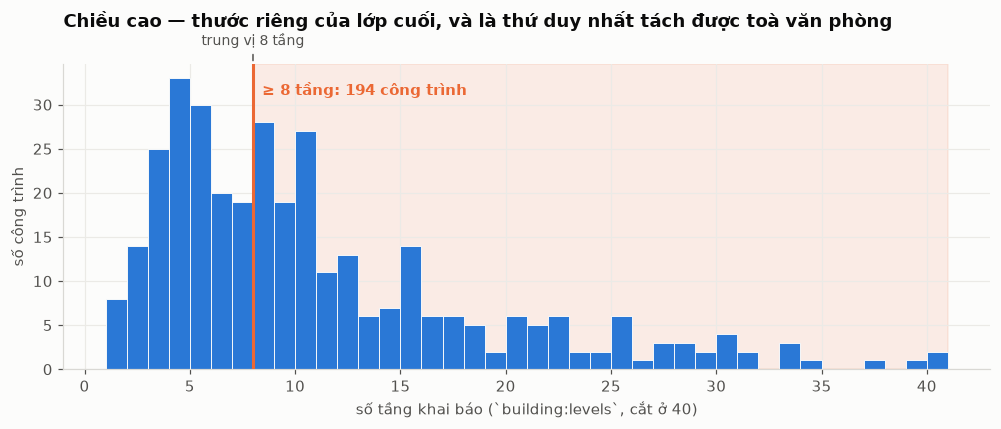

In [7]:
import matplotlib.pyplot as plt

BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#b8b7b2"
INK, MUTED, BG = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "axes.edgecolor": "#d9d8d4",
        "axes.grid": True,
        "grid.color": "#ebeae6",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "text.color": INK,
        "axes.labelcolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)


def fmt(x, n=0):
    return f"{x:,.{n}f}".translate(str.maketrans(",.", ".,"))


# GOLD nội bộ: dòng TỰ KHAI là văn phòng bằng tag (`building=office` hoặc `office=*` trên
# polygon). Đo xem chiều cao và diện tích tách nhóm này khỏi phần còn lại tới đâu.
gold = vp[vp["building"].eq("office") | (vp["office"].notna() & vp["is_area"])].copy()
khac = vp[~vp.index.isin(gold.index)]
print(f"gold nội bộ (tự khai văn phòng): {len(gold):,} | phần còn lại: {len(khac):,}")
print()
print(f"{'':28s} {'gold':>10s} {'còn lại':>10s}")
for ten, f in [
    ("số tầng trung vị", lambda d: d["levels"].median()),
    ("% có ≥ 8 tầng", lambda d: d["levels"].ge(8).mean() * 100),
    ("diện tích trung vị m²", lambda d: d.loc[d["is_area"], "area_m2"].median()),
    ("% là polygon", lambda d: d["is_area"].mean() * 100),
    ("% có tên", lambda d: d["name"].notna().mean() * 100),
]:
    print(f"  {ten:26s} {f(gold):10.1f} {f(khac):10.1f}")

# QUÉT NGƯỠNG số tầng — để dữ liệu chỉ chỗ cắt "toà văn phòng" thay vì đoán.
_p = vp[vp["is_area"] & vp["levels"].notna()]
print(f"\nquét ngưỡng số tầng trên {len(_p):,} polygon có khai số tầng:")
for T in [3, 5, 8, 10, 15, 20]:
    m = _p["levels"].ge(T)
    print(
        f"  ≥ {T:2d} tầng: {m.sum():5,} dòng | diện tích trung vị {fmt(_p.loc[m, 'area_m2'].median())} m²"
        f" | có tên {_p.loc[m, 'name'].notna().mean():.0%}"
    )
print("→ Độ phủ TÊN tăng theo chiều cao: toà càng cao càng được đặt tên. Cùng logic 'người map")
print("  đặt tên cho thứ họ coi là MỘT NƠI' của lớp giải trí, ở đây áp cho chiều dọc.")

TANG_CAO = 8
vp["cao_tang"] = vp["levels"].ge(TANG_CAO).fillna(False)

fig, ax = plt.subplots(figsize=(9.2, 4.0))
_h = _p["levels"].clip(upper=40)
ax.hist(_h, bins=range(1, 42), color=BLUE, edgecolor=BG, linewidth=0.6)
ax.axvline(TANG_CAO, color=ORANGE, linewidth=2, zorder=5)
ax.axvspan(TANG_CAO, 41, color=ORANGE, alpha=0.11, zorder=0)
ax.annotate(
    f"≥ {TANG_CAO} tầng: {fmt(int(_p['levels'].ge(TANG_CAO).sum()))} công trình",
    (TANG_CAO, 0.94),
    xycoords=("data", "axes fraction"),
    ha="left",
    va="top",
    fontsize=9.5,
    color=ORANGE,
    fontweight="bold",
    xytext=(6, 0),
    textcoords="offset points",
)
ax.annotate(
    f"trung vị {fmt(_p['levels'].median(), 0)} tầng",
    (_p["levels"].median(), 1.0),
    xytext=(_p["levels"].median(), 1.05),
    xycoords=("data", "axes fraction"),
    textcoords=("data", "axes fraction"),
    ha="center",
    va="bottom",
    fontsize=9,
    color=MUTED,
    arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=1),
)
ax.set_xlabel("số tầng khai báo (`building:levels`, cắt ở 40)")
ax.set_ylabel("số công trình")
ax.set_title(
    "Chiều cao — thước riêng của lớp cuối, và là thứ duy nhất tách được toà văn phòng",
    pad=24,
    loc="left",
)
fig.tight_layout()
plt.show()

### REVIEW — chiều cao, và giới hạn của một lớp định nghĩa bằng phủ định

**Soi gì:** nhóm tự khai văn phòng (`gold`, 941 dòng) so với phần còn lại (4.175); quét 6
ngưỡng số tầng.

**Tìm được:**
- **Chiều cao KHÔNG tách được nhóm ở phần thân phân phối, chỉ tách ở ĐUÔI.** Trung vị số
  tầng của hai nhóm **bằng nhau: 8,0 và 8,0**. Thứ khác nhau là tỷ lệ chạm ngưỡng:
  **13,0% so với 1,7%** — hơn 7 lần. Nói cách khác chiều cao là một tín hiệu hiếm và mạnh,
  không phải một thang đo liên tục dùng để xếp hạng.
- **Nhóm tự khai văn phòng NHỎ hơn hẳn về diện tích, không to hơn:** trung vị
  **537 m² so với 3.063 m²**, tức chỉ bằng **1/5,7**. (Bản review trước của notebook này
  viết "cao hơn và to hơn" — sai cả hai vế so với chính bảng số ngay trên nó. Lý do vế
  diện tích lật ngược: phần "còn lại" chứa các ô đất `landuse=commercial` rộng hàng hecta,
  còn `gold` là các footprint toà nhà đơn lẻ.)
- **Độ phủ tên tăng theo chiều cao** — 82% → 91% → 98% từ ngưỡng ≥3 lên ≥15 tầng, rồi
  **tụt về 96% ở ≥20 tầng** (n=50, tức 2 dòng). Xu hướng có thật, nhưng không đơn điệu.
- **`building:levels` chỉ phủ một phần nhỏ:** 982/143.833 = **0,7%** bộ vào,
  338/2.698 = **12,5%** bộ final. Ngoài nhóm đó, chiều cao vô hình.

**Quyết định:** `cao_tang` (≥ 8 tầng) làm cờ, KHÔNG làm điều kiện lọc. Ngưỡng 8 tầng là
**đặt tay** và cố ý kế thừa đúng ngưỡng mà `eda_chungcu` dùng cho nhóm `morph_review` — để
hai lớp nói cùng một ngôn ngữ về món nợ chung.

**Phải nói thẳng:** lớp này không có cách nào đạt độ tin của lớp trường học (96,7%) hay lớp
y tế (99,8%). Nó không có nguồn thứ hai để đối chứng, không có thước ngoài, và định nghĩa
của nó là phủ định. Con số của nó là **cận trên của một tập ứng viên**, không phải một
danh sách toà văn phòng đã xác minh. Đo được bằng mẫu ngẫu nhiên 50 dòng ở cell cuối:
**46/50 = 92% đúng**.

→ TỰ PHÊ DUYỆT, đi tiếp.

## Bước 3 — precision: mỗi luật một cell

In [8]:
candidates = vp.copy()
remaining = candidates.copy()
remaining["mixed_use"] = False
removed_parts = []


def co_bang_chung_vp(df):
    """Bằng chứng VĂN PHÒNG — tag tự khai hoặc hình thái cao tầng."""
    return df["building"].eq("office") | df["office"].notna() | (df["levels"].ge(8) & df["is_area"])


def drop_rule(cond, rule, n=6, tha_vp=False):
    global remaining
    m = cond.reindex(remaining.index, fill_value=False)
    if tha_vp:
        tha = m & co_bang_chung_vp(remaining)
        if tha.any():
            remaining.loc[tha, "mixed_use"] = True
            print(
                f"  ⊙ {tha.sum()} dòng có bằng chứng VĂN PHÒNG → GIỮ, cờ mixed_use:",
                remaining.loc[tha, "name"].dropna().head(5).tolist(),
            )
            m = m & ~tha
    hit = remaining[m]
    print(f"{rule}: xoá {len(hit):,}  →  còn lại {len(remaining) - len(hit):,}")
    print("  mẫu :", hit["name"].dropna().head(n).tolist())
    conflict = hit[co_bang_chung_vp(hit)]
    if len(conflict):
        print(
            f"  ⚠ {len(conflict)} dòng có bằng chứng văn phòng:",
            conflict["name"].dropna().head(8).tolist(),
        )
    removed_parts.append(hit.assign(drop_reason=rule))
    remaining = remaining[~m]


print(f"vào bước 3: {len(remaining):,} dòng")

vào bước 3: 5,115 dòng


In [9]:
# LUẬT 1 — hạ tầng đường. Lần thứ CHÍN và cuối cùng của chuỗi. Chín lớp, chín lần cùng một
# luật đứng đầu: ở OSM Việt Nam, **tên trạm xe buýt là nguồn nhiễu số một của mọi lớp POI**.
INFRA = (
    remaining["highway"].notna()
    | remaining["public_transport"].notna()
    | remaining["railway"].notna()
    | remaining["aeroway"].notna()
)
print(
    "tên có 'toà nhà/công ty' mà dính luật này:",
    int((INFRA & remaining["name_norm"].str.contains(r"toa nha|cong ty", na=False)).sum()),
)
print()
drop_rule(INFRA, "HA_TANG_DUONG")

tên có 'toà nhà/công ty' mà dính luật này: 613

HA_TANG_DUONG: xoá 699  →  còn lại 4,416
  mẫu : ['Tòa nhà King Palace - 108 Nguyễn Trãi', '196 Giải Phóng - Ngân hàng Nông nghiệp & PTNT Chi nhánh Nam Hà Nội', 'Tòa nhà Indochina Tower - Đối diện ĐHQG Hà Nội', 'Công ty thuốc lá Thăng Long - 235 Nguyễn Trãi', 'Tổng công ty Đường sắt Việt Nam - 116 Lê Duẩn', 'Trước tòa nhà Artemis - Đường Tôn Thất Tùng kéo dài']
  ⚠ 7 dòng có bằng chứng văn phòng: ['Thien Phu Bus Stop', 'Toàn Thắng', 'Hoi An Express (Bus)', 'Go Travel (Shuttle Bus)', 'Công Ty Cầu 5 Thăng Long', 'Hahn Café']


In [10]:
# LUẬT 2 — Ô ĐẤT, không phải công trình. `landuse=commercial` vẽ ranh khu đất dịch vụ.
# Lớp thương mại đã CỐ Ý không nhận nhóm này và bàn giao xuống đây; quyết định cuối là:
# giữ nếu CÓ TÊN (tên mô tả chính polygon được vẽ — ngoại lệ polygon đã luận chứng từ lớp
# nhà ở), loại nếu vô danh và không có công trình nào bên trong.
DAT_VO_DANH = (
    remaining["landuse"].eq("commercial")
    & remaining["name"].isna()
    & remaining["office"].isna()
    & remaining["building"].isna()
)
print(
    f"`landuse=commercial` tổng: {int(remaining['landuse'].eq('commercial').sum()):,}"
    f" — vô danh và không công trình: {int(DAT_VO_DANH.sum()):,}"
)
print()
drop_rule(DAT_VO_DANH, "O_DAT_VO_DANH")

`landuse=commercial` tổng: 1,239 — vô danh và không công trình: 886

O_DAT_VO_DANH: xoá 886  →  còn lại 3,530
  mẫu : []


In [11]:
# LUẬT 3 — họ tag thuộc LỚP KHÁC. Bảy lớp trước đã dọn phần lớn, đây là phần lọt lưới qua
# nhánh TÊN (một công ty tên "Công ty TNHH Nhà hàng ABC" thì vẫn là nhà hàng).
NGOAI_LOP = (
    remaining["shop"].notna()
    | remaining["healthcare"].notna()
    | remaining["tourism"].notna()
    | remaining["leisure"].notna()
    | remaining["government"].notna()
    | remaining["military"].notna()
    | remaining["amenity"].isin(
        [
            "restaurant",
            "cafe",
            "fast_food",
            "bar",
            "pub",
            "parking",
            "fuel",
            "bank",
            "atm",
            "pharmacy",
            "school",
            "kindergarten",
            "college",
            "university",
            "hospital",
            "clinic",
            "marketplace",
            "place_of_worship",
            "toilets",
            "bus_station",
            "townhall",
            "police",
            "post_office",
            "courthouse",
            "library",
            "cinema",
            # ── THIẾT BỊ ĐẶT NHỜ ĐỊA ĐIỂM (thẩm định 2026-08-09) ──
            # Vật thể là THIẾT BỊ, cái tên là ĐỊA ĐIỂM CHỦ: "TNGo - Bảo tàng Chiến thắng B52",
            # "TNGo - Học viện Ngoại giao", "TNGo - Vincom Phạm Ngọc Thạch". Chúng lọt vào lớp
            # qua nhánh TÊN, và vì là node trần không mang `highway`/`public_transport` nên luật
            # hạ tầng đường KHÔNG bắt được. Đây là bẫy "tên là mốc tham chiếu" ở dạng thuần nhất.
            # Đo 2026-08-09: 12 dòng rải ở 4 lớp. Ở quy mô toàn quốc xe đạp công cộng đang mở
            # rộng nhanh, nên đây là danh sách chặn theo TAG (không theo tên) để khỏi phải đuổi
            # theo từng thương hiệu.
            "bicycle_rental",
            "vending_machine",
            "parcel_locker",
        ]
    )
)
print()
drop_rule(NGOAI_LOP, "TAG_LOP_KHAC", tha_vp=True)


  ⊙ 48 dòng có bằng chứng VĂN PHÒNG → GIỮ, cờ mixed_use: ['TT bảo hành Nokia', 'cửa hàng Flamingo Motorbike Tours / Rentals', 'The Sinh Tourist', 'Du Lịch Danh Danh', 'Narenca publisher showroom']
TAG_LOP_KHAC: xoá 349  →  còn lại 3,181
  mẫu : ['CongTy TNHH Hong Ly', 'Vietcombank - Chi nhánh Chương Dương', 'Vietcombank - Chi nhánh Hoàn Kiếm - PGD Bạch Mai', 'Cty Thái Tuấn', 'Cty may Tây Đô', 'Kho bia CTY Á Châu']


In [12]:
# LUẬT 4 — CÔNG NGHIỆP, ngoài phạm vi MVP. Nhà máy, kho bãi, khu công nghiệp là một lớp
# riêng trong bảng phân loại gốc ("khu công nghiệp: nhà máy, kho bãi") và chưa tới lượt.
#
# ⚠ ĐÂY LÀ LỚP CUỐI CỦA DÂY CHUYỀN — luật xoá ở đây KHÔNG CÓ LƯỚI ĐỠ. Vì thế mọi điều kiện
# xoá phải là DANH SÁCH, không được là ký tự đại diện: `man_made.notna()` cũ đã ăn oan 6
# dòng ("Toà Nhà Golden Hill" `man_made=tower`, "Đài Khí tượng Thuỷ văn Đồng Nai"
# `monitoring_station`), và `man_made` có ~80 giá trị nên ở SCOPE=vn nó sẽ ăn lớn hơn nhiều
# bậc mà không ai thấy.
#
# ── SỬA 2026-08-09: tách hai nhánh, vì hai nhánh có ĐỘ TIN KHÁC HẲN NHAU ──
# TAG mô tả VẬT THỂ: `landuse=industrial`, `building=warehouse` là lời tự khai "tôi là nhà
#   máy/kho". `office=*` KHÔNG cãi lại được — nó chỉ nói có một doanh nghiệp ở đây, mà nhà
#   máy nào cũng có. Miễn trừ cũ `~co_bang_chung_vp` (gồm `office.notna()`) vì thế đã giữ
#   lại nhầm nhà máy: đo 2026-08-09 có 7 dòng (`landuse=industrial` + `office=company`:
#   "Ponaflex", "Nhà máy nước Mai Dịch"…). Nhánh TAG nay chỉ miễn trừ HÌNH THÁI
#   (`building=office` hoặc ≥8 tầng) — thứ duy nhất mô tả chính công trình.
# TÊN thì ngược lại, yếu và hay là MỐC THAM CHIẾU. Giữ nguyên miễn trừ rộng
#   `~co_bang_chung_vp`: đo thử siết nhánh này thì 30 dòng bị đụng, đọc mắt ≥10 dòng sai
#   ("Điểm Giao Dịch Viettel KCN Thạch Thất", "Xí nghiệp Quản lý và Phát triển nhà Cầu
#   Giấy") = 33% ≫ ngưỡng 1% ⇒ BÁC.
# Hai vá nhỏ ở chính chuỗi ký tự, cùng loại lỗi "tên là mốc tham chiếu":
#   · `kcn|khu cong nghiep` chỉ tính khi đứng ĐẦU tên ("KCN Đại An"). Ở giữa tên nó là ĐỊA
#     CHỈ: đo 7/7 dòng khớp-giữa đều không phải khu công nghiệp ("Argibank KCN Tân Thành",
#     "căn tin cty megatech-kcn Chơn Thành") ⇒ 100% sai nếu xoá.
#   · tên đã nói "toà nhà / cao ốc / văn phòng" thì từ khoá công nghiệp thua ("Cao ốc văn
#     phòng và kho Yteco" — 1 dòng ở 7 tỉnh).
# Giữ nguyên mọi từ khoá không gom được gì ở 7 tỉnh (`khu che xuat`, `\btba\b`…): chúng vô
# hại ở đây và sẽ có việc ở SCOPE=vn.
MAN_MADE_CONG_NGHIEP = [
    "works", "water_works", "wastewater_plant", "gasometer", "silo", "storage_tank",
    "pipeline", "kiln", "mineshaft", "adit", "petroleum_well", "oil_well", "chimney",
    "crane", "goods_conveyor", "quarry",
]
CN_TAG = (
    remaining["landuse"].isin(["industrial", "warehouse", "quarry", "port"])
    | remaining["building"].isin(["industrial", "warehouse", "factory", "hangar"])
    | remaining["man_made"].isin(MAN_MADE_CONG_NGHIEP)
    | remaining["power"].notna()
)
RX_CN = (
    r"nha may|xi nghiep|kho bai|\bkho \b|xuong san xuat|tram bien ap|\btba\b|nha kho"
)
RX_KCN = r"(?:\bkcn\b|khu cong nghiep|khu che xuat)"
_nn = remaining["name_norm"]
TEN_VP_MANH = _nn.str.contains(r"toa nha|\bcao oc\b|\btower\b|van phong|\boffice\b", na=False)
CN_TEN = (
    _nn.str.contains(RX_CN, na=False) | _nn.str.match(RX_KCN + r"\b", na=False)
) & ~TEN_VP_MANH
# HÌNH THÁI = bằng chứng duy nhất cãi lại được một tag công nghiệp.
HINH_THAI_VP = remaining["building"].eq("office") | (
    remaining["levels"].ge(8) & remaining["is_area"]
)
CONG_NGHIEP = (CN_TAG & ~HINH_THAI_VP) | (CN_TEN & ~co_bang_chung_vp(remaining))
print(
    f"nhánh TAG {int(CN_TAG.sum()):,} (miễn trừ hình thái {int((CN_TAG & HINH_THAI_VP).sum())})"
    f" | nhánh TÊN {int(CN_TEN.sum()):,}"
    f" (miễn trừ bằng chứng VP {int((CN_TEN & co_bang_chung_vp(remaining)).sum())})"
)
print()
drop_rule(CONG_NGHIEP, "CONG_NGHIEP_NGOAI_MVP")

nhánh TAG 470 (miễn trừ hình thái 2) | nhánh TÊN 64 (miễn trừ bằng chứng VP 33)

CONG_NGHIEP_NGOAI_MVP: xoá 475  →  còn lại 2,706
  mẫu : ['Công ty cổ phần nhựa Thiếu Niên Tiền Phong', 'Công ty CPTM dịch vụ và du lịch Hạ Long', 'Công Ty Cp Công Nghiệp điện Hải Phòng', 'Công ty Kiểm toán Việt Nam', 'Công ty KUMHO Việt Nam', 'Công Ty CP Kỹ Nghệ Thực Phẩm Vifon Việt Nam']
  ⚠ 6 dòng có bằng chứng văn phòng: ['Mỹ Sơn', 'Ponaflex', 'Công Ty SUHEUNG VIETNAM', 'Công ty Cổ phần Hơi Kỹ Nghệ Que Hàn', 'Nhà máy nước Mai Dịch', 'Tosadenshi Group']


In [13]:
# LUẬT 5 — tên nói thẳng là loại khác + MỐC THAM CHIẾU.
# MỞ RỘNG 2026-08-09, do MẪU NGẪU NHIÊN 50 DÒNG chỉ ra (xem cell cuối): 6/50 dòng sai, và
# 4 trong số đó cùng một họ — vật thể là BỘ PHẬN của toà nhà hoặc là HẠ TẦNG, lọt vào qua
# nhánh TÊN. Bốn nhóm bổ sung, mỗi nhóm đo riêng trước khi nhận:
#   · bộ phận toà nhà (sảnh / lobby / drop-off / thang máy): chạm 8 dòng, miễn trừ 5 nhờ
#     bằng chứng VP ("Công ty TNHH Thang Máy Hải Phát" — công ty thang máy, không phải cái
#     thang máy), xoá 3 ("Seine/Thames/Hudson Tower Drop-Off"). Đọc mắt: 3/3 đúng.
#   · ký túc xá → lớp nhà ở: chạm 2, xoá 1 ("Ký túc xá May 10"). 1/1 đúng.
#   · trạm viễn thông / BTS → hạ tầng: xoá 1. 1/1 đúng.
#   · lầu / đền / miếu → di tích: xoá 1 ("Lầu Chuông"). 1/1 đúng.
# Tổng 6 dòng xoá, 0 dòng sai trên 12 dòng luật chạm tới = 0% ≪ ngưỡng 1%.
# CỐ Ý KHÔNG thêm `^thap ` dù "Lầu/Tháp" cùng họ: "Tháp" là tên rất thường của chính TOÀ
# VĂN PHÒNG ("Tháp Bitexco"), ở SCOPE=vn nó sẽ ăn nhầm hàng loạt.
TEN_LOAI_KHAC = remaining["name_norm"].str.contains(
    r"benh vien|phong kham|nha thuoc|truong (?:tieu hoc|thcs|thpt|mam non|mau giao|dai hoc)"
    r"|khach san|nha nghi|sieu thi|trung tam thuong mai|\bcay xang\b|tram xang|\bchung cu\b"
    r"|\bnha tho\b|\bchua \b|nghia trang|\bbai do xe\b|ben xe|cong vien|\bubnd\b|\bcong an\b"
    r"|\blobby\b|\bsanh\b|drop.?off|thang may|\belevator\b|\breception\b"
    r"|ky tuc xa|\bktx\b"
    r"|tram vien thong|tram thu phat|tram bts|cot ang ten"
    r"|^lau |\bden tho\b|\bmieu\b",
    na=False,
) & ~co_bang_chung_vp(remaining)
print()
drop_rule(TEN_LOAI_KHAC, "TEN_LOAI_KHAC")


TEN_LOAI_KHAC: xoá 11  →  còn lại 2,695
  mẫu : ['CÂY XĂNG TNHH DV 99', 'Lầu Chuông', 'Thames Tower Drop-Off', 'Hudson Tower Drop-Off', 'Seine Tower Drop-Off', 'Trạm Viễn Thông Núi Tao Phùng']


In [14]:
MOC = remaining["name_norm"].str.contains(
    r"^(?:doi dien|truoc cong|he truoc|he doi dien|diem xen|cong khu|ben canh|duong vao|qua san)",
    na=False,
)
print()
drop_rule(MOC, "MOC_THAM_CHIEU")


MOC_THAM_CHIEU: xoá 0  →  còn lại 2,695
  mẫu : []


In [15]:
# CỔNG HẬU KIỂM.
removed = pd.concat(removed_parts)
assert len(removed) + len(remaining) == len(candidates), "thất thoát dòng giữa các luật"

LUAT_CO_Y = {"TAG_LOP_KHAC", "CONG_NGHIEP_NGOAI_MVP", "O_DAT_VO_DANH"}
conflict = removed[co_bang_chung_vp(removed)]
print(f"POI có bằng chứng VĂN PHÒNG nhưng bị xoá: {len(conflict)} — phân theo luật:")
print(conflict["drop_reason"].value_counts().to_string() or "  (không có)")
cf_ngoai_y = conflict[~conflict["drop_reason"].isin(LUAT_CO_Y)]
print(f"\n── do LUẬT NGOÀI Ý (phải nhỏ): {len(cf_ngoai_y)} ──")
if len(cf_ngoai_y):
    print(cf_ngoai_y[["name", "office", "building", "levels", "drop_reason"]].head(25).to_string())
assert len(cf_ngoai_y) <= 30, f"{len(cf_ngoai_y)} dòng văn phòng bị luật NGOÀI Ý xoá"

print("\n== tổng hợp theo luật ==")
print(removed["drop_reason"].value_counts().to_string())
print("\n== nhóm rủi ro nhất: tên có 'toà nhà/tower' mà vẫn bị xoá ==")
risky = removed[removed["name_norm"].str.contains(r"toa nha|\btower\b", na=False)]
print(f"{len(risky)} dòng — {risky['drop_reason'].value_counts().to_dict()}")
print(" ", risky["name"].dropna().head(8).tolist())

POI có bằng chứng VĂN PHÒNG nhưng bị xoá: 13 — phân theo luật:
drop_reason
HA_TANG_DUONG            7
CONG_NGHIEP_NGOAI_MVP    6

── do LUẬT NGOÀI Ý (phải nhỏ): 7 ──
                           name        office building  levels    drop_reason
9570         Thien Phu Bus Stop  travel_agent      NaN     NaN  HA_TANG_DUONG
10781                Toàn Thắng  travel_agent      NaN     NaN  HA_TANG_DUONG
13209      Hoi An Express (Bus)  travel_agent      NaN     NaN  HA_TANG_DUONG
13336   Go Travel (Shuttle Bus)  travel_agent      NaN     NaN  HA_TANG_DUONG
29985  Công Ty Cầu 5 Thăng Long       company      NaN     NaN  HA_TANG_DUONG
35953                       NaN  travel_agent      NaN     NaN  HA_TANG_DUONG
62168                 Hahn Café  travel_agent      NaN     NaN  HA_TANG_DUONG

== tổng hợp theo luật ==
drop_reason
O_DAT_VO_DANH            886
HA_TANG_DUONG            699
CONG_NGHIEP_NGOAI_MVP    475
TAG_LOP_KHAC             349
TEN_LOAI_KHAC             11

== nhóm rủi ro nhất: tên c

In [16]:
# ── CỔNG RECALL CỦA BƯỚC 3 — thước quan trọng nhất của lớp này ──────────────
# Cổng ở bước 1 chỉ chứng minh "đã tuyển đủ". Nhưng dòng mất thật sự là mất ở BƯỚC 3:
# 2.418 dòng bị năm luật xoá. Đo hai chiều:
#   (a) TÍN HIỆU MẠNH sống sót bao nhiêu phần trăm qua toàn bộ bước 3;
#   (b) đọc mắt một mẫu ngẫu nhiên của chính tập BỊ XOÁ, đếm dòng xoá oan.
print("(a) TỶ LỆ SỐNG SÓT QUA BƯỚC 3, theo tín hiệu")
_TIN_HIEU = {
    "building=office": candidates["building"].eq("office"),
    "≥ 8 tầng & polygon": candidates["levels"].ge(8) & candidates["is_area"],
    "office=* trên polygon": candidates["office"].notna() & candidates["is_area"],
    "office=* (mọi nơi)": candidates["office"].notna(),
    "landuse=commercial CÓ TÊN": candidates["landuse"].eq("commercial") & candidates["name"].notna(),
    "tên 'toà nhà / cao ốc / tower'": candidates["name_norm"].str.contains(
        r"toa nha|\bcao oc\b|\btower\b", na=False
    ),
    "tên 'văn phòng'": candidates["name_norm"].str.contains(r"van phong", na=False),
    "tên 'công ty / cty / tnhh'": candidates["name_norm"].str.contains(
        r"cong ty|\bcty\b|\btnhh\b", na=False
    ),
}
_song = candidates.index.isin(remaining.index)
for ten, m in _TIN_HIEU.items():
    n, s = int(m.sum()), int((m & _song).sum())
    print(f"  {ten:32s} {s:5,}/{n:<5,} = {s / n:6.1%}")
print("  → Tín hiệu TAG và HÌNH THÁI gần như không mất dòng nào. Nhánh TÊN mất nhiều là ĐÚNG:")
_ct = removed["name_norm"].str.contains(r"cong ty|\bcty\b|\btnhh\b", na=False)
print(
    f"    trong {int(_ct.sum()):,} dòng 'công ty' bị xoá,"
    f" {int((_ct & removed['highway'].eq('bus_stop')).sum()):,} là `highway=bus_stop`"
    " — tên hãng gắn trên trạm buýt, không phải văn phòng."
)

print("\n(b) MẪU NGẪU NHIÊN 50 DÒNG BỊ XOÁ (seed 20260809) — đếm dòng xoá oan")
_mx = removed.sample(50, random_state=20260809)
for i, (_, r) in enumerate(_mx.iterrows(), 1):
    print(
        f"{i:2d}. {str(r['name'])[:46]:46s} | {r['drop_reason']:22s}"
        f" | {'poly' if r['is_area'] else 'node'}"
        f" | hw={str(r['highway'])[:9]:9s} lu={str(r['landuse'])[:11]:11s} b={str(r['building'])[:10]}"
    )


(a) TỶ LỆ SỐNG SÓT QUA BƯỚC 3, theo tín hiệu
  building=office                    456/456   = 100.0%
  ≥ 8 tầng & polygon                 194/194   = 100.0%
  office=* trên polygon              530/536   =  98.9%
  office=* (mọi nơi)               1,550/1,563 =  99.2%
  landuse=commercial CÓ TÊN          288/349   =  82.5%
  tên 'toà nhà / cao ốc / tower'     200/311   =  64.3%
  tên 'văn phòng'                     75/126   =  59.5%
  tên 'công ty / cty / tnhh'         661/1,794 =  36.8%
  → Tín hiệu TAG và HÌNH THÁI gần như không mất dòng nào. Nhánh TÊN mất nhiều là ĐÚNG:
    trong 1,133 dòng 'công ty' bị xoá, 541 là `highway=bus_stop` — tên hãng gắn trên trạm buýt, không phải văn phòng.

(b) MẪU NGẪU NHIÊN 50 DÒNG BỊ XOÁ (seed 20260809) — đếm dòng xoá oan
 1. Công ty Bê tông Hùng Vương                     | HA_TANG_DUONG          | node | hw=bus_stop  lu=nan         b=nan
 2. Công ty TNHH Mộc Vân Phong                     | CONG_NGHIEP_NGOAI_MVP  | poly | hw=nan       lu=nan         

In [17]:
clean = remaining.copy()
out_keep = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3.parquet"
out_drop = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3_bi_xoa.parquet"
clean.drop(columns="tags_dict").to_parquet(out_keep, index=False)
removed.drop(columns="tags_dict").to_parquet(out_drop, index=False)
print(f"giữ : {len(clean):,} → {out_keep.name}")
print(f"xoá : {len(removed):,} → {out_drop.name}\n")
for ten, m in BR.items():
    tong = int(m.reindex(candidates.index, fill_value=False).sum())
    song = int(m.reindex(clean.index, fill_value=False).sum())
    print(f"  {ten:24s} {song:5,}/{tong:<6,} = {song / tong:.0%}" if tong else f"  {ten:24s} —")

giữ : 2,695 → poi_vanphong_7tinh_b3.parquet
xoá : 2,420 → poi_vanphong_7tinh_b3_bi_xoa.parquet

  A tag văn phòng/TM       2,582/3,589  = 72%
  B tên                    1,067/2,487  = 43%
  C hình thái ≥8 tầng        194/194    = 100%
  D nợ từ lớp nhà ở           38/38     = 100%


## Bước 4 — ĐO, không quyết

In [18]:
# [DATA] sinh cột: hang_vp, container_uid, fragment_group
nn_c = clean["name_norm"]
hang = pd.Series("DIEM_DOANH_NGHIEP", index=clean.index)
# `TOA_VAN_PHONG` phải là một CÔNG TRÌNH, nên đòi `is_area`. Trước đây không đòi: 33/592
# dòng (5,6%) là NODE mang tên "Toà Nhà X" hoặc `building=office` đặt trên điểm — chúng là
# điểm chỉ chỗ, không có mặt bằng, và làm con số "số TOÀ" phồng lên. Chúng xuống
# `DIEM_DOANH_NGHIEP`, không mất dòng nào.
hang[
    (
        clean["building"].eq("office")
        | clean["cao_tang"]
        | nn_c.str.contains(r"toa nha|\bcao oc\b|\btower\b|\bbuilding\b", na=False)
    )
    & clean["is_area"]
    # `building` tự khai là loại công trình KHÁC thì thắng cả chiều cao: một khối
    # `building=warehouse` 8 tầng hay `building=industrial` 33 tầng không phải toà văn
    # phòng, `building=parking` là nhà để xe. Đo: 4 dòng, xuống `DIEM_DOANH_NGHIEP`,
    # không mất dòng nào. (`retail` KHÔNG loại — "Tòa nhà Zen Plaza" 12 tầng là toà thật.)
    & ~clean["building"].isin(["warehouse", "industrial", "parking"])
] = "TOA_VAN_PHONG"
hang[clean["office"].isin(["diplomatic"])] = "NGOAI_GIAO"
hang[clean["office"].isin(["ngo", "association", "charity", "religion", "political_party"])] = (
    "TO_CHUC_XA_HOI"
)
hang[clean["landuse"].eq("commercial") & clean["building"].isna() & clean["office"].isna()] = (
    "O_DAT_DICH_VU"
)
clean["hang_vp"] = hang
# Món nợ từ lớp nhà ở là một TRẠNG THÁI ("chưa biết chung cư hay văn phòng"), không phải
# một HẠNG. Trước đây nó được gán đè lên `hang_vp` và chạy CUỐI, nên nuốt trọn 38 dòng —
# cả 38 đều có `levels ≥ 8` tức là đều thuộc `TOA_VAN_PHONG`. Nay tách thành CỜ riêng.
clean["no_tu_lop_nha_o"] = (
    clean["uid"].isin(set(pq.read_table(MORPH_PATH, columns=["uid"]).to_pandas()["uid"]))
    if MORPH_PATH.exists()
    else False
)

print(clean["hang_vp"].value_counts().to_string())
print(
    f"cờ no_tu_lop_nha_o: {int(clean['no_tu_lop_nha_o'].sum())} dòng"
    f" — hạng của chúng: {clean.loc[clean['no_tu_lop_nha_o'], 'hang_vp'].value_counts().to_dict()}"
)
print()
print("office ngành nghề:", clean["office"].value_counts().head(10).to_dict())
print(
    f"cao ≥ {TANG_CAO} tầng: {int(clean['cao_tang'].sum()):,}"
    f" | có `building:levels`: {int(clean['levels'].notna().sum()):,}"
)

from shapely import wkb
from shapely.geometry import Point
from shapely.strtree import STRtree

PTS = [Point(x, y) for x, y in zip(clean["lng"].values, clean["lat"].values)]
TREE = STRtree(PTS)
UIDS = clean["uid"].values
vung = clean[clean["is_area"] & clean["geometry_wkb"].notna()].copy()
vung["_geom"] = [wkb.loads(bytes(x)) for x in vung["geometry_wkb"]]
vung = vung[[g.is_valid and g.area > 0 for g in vung["_geom"]]]
container = {}
for i, geom in vung.sort_values("area_m2", ascending=False)["_geom"].items():
    self_uid = vung.at[i, "uid"]
    q = TREE.query(geom)
    if not len(q):
        continue
    for j in q[[geom.contains(PTS[k]) for k in q]]:
        if UIDS[j] != self_uid:
            container[UIDS[j]] = self_uid
clean["container_uid"] = clean["uid"].map(container)
co_ten = clean["name"].notna()
key = clean.loc[co_ten, ["h3_r8", "name_norm"]].astype(str).agg("|".join, axis=1)
clean["fragment_group"] = key[key.duplicated(keep=False)].reindex(clean.index)

n_row, n_ct = len(clean), int(clean["container_uid"].notna().sum())
print(f"\ndòng nằm trong polygon văn phòng khác (công ty thuê chỗ trong toà): {n_ct:,}")
print(f"  → đếm TOÀ: {n_row - n_ct:,} thay vì {n_row:,}")
print("  Ở lớp này `container_uid` có nghĩa RIÊNG: nó tách 'toà nhà' khỏi 'doanh nghiệp thuê")
print("  chỗ trong toà' — hai thực thể khác nhau, và bài toán trạm sạc chỉ cần cái thứ nhất.")
print(
    f"nhóm trùng tên cùng ô H3: {clean['fragment_group'].nunique():,} nhóm,"
    f" {clean['fragment_group'].notna().sum():,} dòng"
)

hang_vp
DIEM_DOANH_NGHIEP    1839
TOA_VAN_PHONG         591
O_DAT_DICH_VU         220
TO_CHUC_XA_HOI         45
cờ no_tu_lop_nha_o: 38 dòng — hạng của chúng: {'TOA_VAN_PHONG': 36, 'DIEM_DOANH_NGHIEP': 2}

office ngành nghề: {'company': 801, 'yes': 215, 'telecommunication': 69, 'estate_agent': 50, 'newspaper': 41, 'lawyer': 36, 'it': 31, 'travel_agent': 29, 'insurance': 26, 'association': 24}
cao ≥ 8 tầng: 195 | có `building:levels`: 338



dòng nằm trong polygon văn phòng khác (công ty thuê chỗ trong toà): 107
  → đếm TOÀ: 2,588 thay vì 2,695
  Ở lớp này `container_uid` có nghĩa RIÊNG: nó tách 'toà nhà' khỏi 'doanh nghiệp thuê
  chỗ trong toà' — hai thực thể khác nhau, và bài toán trạm sạc chỉ cần cái thứ nhất.
nhóm trùng tên cùng ô H3: 16 nhóm, 33 dòng


## Bước 5 — FINAL và bộ CÒN LẠI CUỐI CÙNG của cả chuỗi

In [19]:
final = clean.copy()
out_final = EDA_DIR / f"poi_{LOP}_{SCOPE}_final.parquet"
final.drop(columns="tags_dict").to_parquet(out_final, index=False)
print(f"final: {len(final):,} dòng, {final.shape[1] - 1} cột → {out_final.name}")
print("\nhang_vp:", final["hang_vp"].value_counts().to_dict())
_toa = final[final["hang_vp"].eq("TOA_VAN_PHONG") & final["container_uid"].isna()]
print(
    f"số TOÀ VĂN PHÒNG đúng nghĩa (hang=TOA_VAN_PHONG & không nằm trong toà khác):"
    f" {len(_toa):,}"
)
print(f"  (mọi hạng, chỉ lọc container_uid: {final['container_uid'].isna().sum():,})")
print(f"  trong đó còn treo nợ chung cư/văn phòng: {int(_toa['no_tu_lop_nha_o'].sum())}")
print()
print(
    final.groupby("hang_vp")["province_name"]
    .value_counts()
    .unstack(0)
    .fillna(0)
    .astype(int)
    .to_string()
)

final: 2,695 dòng, 85 cột → poi_vanphong_7tinh_final.parquet

hang_vp: {'DIEM_DOANH_NGHIEP': 1839, 'TOA_VAN_PHONG': 591, 'O_DAT_DICH_VU': 220, 'TO_CHUC_XA_HOI': 45}
số TOÀ VĂN PHÒNG đúng nghĩa (hang=TOA_VAN_PHONG & không nằm trong toà khác): 565
  (mọi hạng, chỉ lọc container_uid: 2,588)
  trong đó còn treo nợ chung cư/văn phòng: 35

hang_vp                DIEM_DOANH_NGHIEP  O_DAT_DICH_VU  TOA_VAN_PHONG  TO_CHUC_XA_HOI
province_name                                                                         
Thành phố Cần Thơ                    147              3              2               3
Thành phố Hà Nội                     603             79            317              28
Thành phố Hải Phòng                   62             14             45               0
Thành phố Hồ Chí Minh                738             67            195              11
Thành phố Đà Nẵng                    169              4             12               2
Tỉnh Quảng Ninh                       34              8

In [20]:
da_thuoc_lop = set(final["uid"])
con_lai = poi[~poi["uid"].isin(da_thuoc_lop)].copy()
out_pool = EDA_DIR / f"poi_extended_{SCOPE}_con_lai_cuoi.parquet"
con_lai.drop(columns="tags_dict").to_parquet(out_pool, index=False)
print(f"bộ vào    : {len(poi):,}")
print(f"đã bóc ra : {len(da_thuoc_lop):,}")
print(f"CÒN LẠI CUỐI CÙNG: {len(con_lai):,}  → {out_pool.name}")
_con = removed["uid"].isin(con_lai["uid"]).sum()
assert _con == len(removed), f"mất {len(removed) - _con} dòng bị luật xoá khỏi bộ còn lại"
print(
    f"✓ {len(removed):,} dòng bị {removed['drop_reason'].nunique()} luật xoá đều nằm lại trong bộ còn lại"
)
for ten_lop in [
    "chungcu",
    "luutru",
    "thuongmai",
    "giaitri",
    "thamquan",
    "truonghoc",
    "benhvien",
    "hanhchinh",
]:
    f = EDA_DIR / f"poi_{ten_lop}_{SCOPE}_final.parquet"
    giao = set(pq.read_table(f, columns=["uid"]).to_pandas()["uid"]) & da_thuoc_lop
    assert not giao, f"{len(giao)} uid trùng với lớp {ten_lop}"
    print(f"✓ không đếm đôi với lớp {ten_lop}")

print("\n── PHẦN CÒN LẠI CUỐI CÙNG là gì? (nguyên liệu cho các lớp sau MVP) ──")
_td = con_lai["tags"].map(parse_tags)
_am = _td.map(lambda t: t.get("amenity"))
print("  amenity:", _am.value_counts().head(12).to_dict())
print(
    "  không có tag phân loại nào:",
    int(
        _td.map(
            lambda t: (
                not (
                    {
                        "amenity",
                        "shop",
                        "office",
                        "tourism",
                        "leisure",
                        "healthcare",
                        "historic",
                        "man_made",
                        "highway",
                        "railway",
                        "power",
                        "landuse",
                        "building",
                        "natural",
                        "place",
                    }
                    & t.keys()
                )
            )
        ).sum()
    ),
)

bộ vào    : 143,827
đã bóc ra : 2,695
CÒN LẠI CUỐI CÙNG: 141,132  → poi_extended_7tinh_con_lai_cuoi.parquet


✓ 2,420 dòng bị 5 luật xoá đều nằm lại trong bộ còn lại
✓ không đếm đôi với lớp chungcu
✓ không đếm đôi với lớp luutru
✓ không đếm đôi với lớp thuongmai
✓ không đếm đôi với lớp giaitri
✓ không đếm đôi với lớp thamquan
✓ không đếm đôi với lớp truonghoc
✓ không đếm đôi với lớp benhvien
✓ không đếm đôi với lớp hanhchinh

── PHẦN CÒN LẠI CUỐI CÙNG là gì? (nguyên liệu cho các lớp sau MVP) ──


  amenity: {'restaurant': 7020, 'cafe': 5758, 'atm': 2667, 'bank': 1750, 'fuel': 1729, 'parking': 1471, 'pharmacy': 1311, 'fast_food': 1003, 'bench': 677, 'shelter': 604, 'bar': 535, 'toilets': 528}
  không có tag phân loại nào: 1217


In [21]:
# ── SỐ CHỐT — mọi con số xuất hiện trong phần kết luận bên dưới đều in ra ở đây ──
# Lý do có cell này: bản kết luận cũ chép tay số của một vòng chạy TRƯỚC và lệch thật
# (139.897 vs 141.356 dòng còn lại; "1.213 dòng công nghiệp" trong khi luật xoá 471).
# Văn xuôi không tự cập nhật được, nên ít nhất phải có chỗ đối chiếu ngay cạnh nó.
_am_cl = con_lai["tags"].map(parse_tags).map(lambda t: t.get("amenity"))
_toa_final = final[final["hang_vp"].eq("TOA_VAN_PHONG") & final["container_uid"].isna()]
print("SỐ CHỐT")
print(f"  final                        : {len(final):,}")
print(f"  TOÀ văn phòng đúng nghĩa     : {len(_toa_final):,}")
print(f"  bị luật xoá                  : {len(removed):,}  {removed['drop_reason'].value_counts().to_dict()}")
print(f"  còn lại cuối cùng            : {len(con_lai):,} = {len(con_lai) / 193509:.1%} bộ gốc")
print(f"  top amenity của bộ còn lại   : {_am_cl.value_counts().head(7).to_dict()}")
print(f"  không mang tag phân loại nào : {int(_td.map(lambda t: not ({'amenity','shop','office','tourism','leisure','healthcare','historic','man_made','highway','railway','power','landuse','building','natural','place'} & t.keys())).sum()):,}")
print(f"  `building:levels` trong final: {int(final['levels'].notna().sum()):,} = {final['levels'].notna().mean():.1%}")

# ── PRECISION — mẫu ngẫu nhiên 50 dòng để đọc mắt thường ──
_mau = final.sample(50, random_state=20260809)
print("\n── MẪU NGẪU NHIÊN 50 DÒNG (seed 20260809) ──")
for i, (_, r) in enumerate(_mau.iterrows(), 1):
    print(
        f"{i:2d}. {str(r['name'])[:52]:52s} | {r['hang_vp']:17s}"
        f" | office={str(r['office'])[:14]:14s} building={str(r['building'])[:11]:11s}"
        f" | {'poly' if r['is_area'] else 'node'}"
    )


SỐ CHỐT
  final                        : 2,695
  TOÀ văn phòng đúng nghĩa     : 565
  bị luật xoá                  : 2,420  {'O_DAT_VO_DANH': 886, 'HA_TANG_DUONG': 699, 'CONG_NGHIEP_NGOAI_MVP': 475, 'TAG_LOP_KHAC': 349, 'TEN_LOAI_KHAC': 11}
  còn lại cuối cùng            : 141,132 = 72.9% bộ gốc
  top amenity của bộ còn lại   : {'restaurant': 7020, 'cafe': 5758, 'atm': 2667, 'bank': 1750, 'fuel': 1729, 'parking': 1471, 'pharmacy': 1311}
  không mang tag phân loại nào : 1,217
  `building:levels` trong final: 338 = 12.5%

── MẪU NGẪU NHIÊN 50 DÒNG (seed 20260809) ──
 1. Tổng Liên đoàn Lao động Việt Nam                     | TOA_VAN_PHONG     | office=union          building=office      | poly
 2. Trung tâm Đăng kiểm Xe cơ giới 60-06D                | O_DAT_DICH_VU     | office=nan            building=nan         | poly
 3. nan                                                  | DIEM_DOANH_NGHIEP | office=nan            building=commercial  | poly
 4. nan                                   

---

## ✅ CHỐT LỚP VĂN PHÒNG — và chốt CẢ CHUỖI

**Phán quyết: ĐẠT, chốt sổ.** Ba thước, đo trên bộ vào 143.823 dòng (vòng chạy lại toàn
chuỗi từ `truonghoc` xuống, 2026-08-09):

| Thước | Số đo | Đánh giá |
| --- | --- | --- |
| **RECALL — bước 3 (thước quan trọng nhất)** | Mẫu ngẫu nhiên **50 dòng BỊ XOÁ**: **0 dòng xoá oan** (cận dưới KTC 95%: **92,9%**). Tín hiệu mạnh sống sót qua 5 luật: `building=office` **100%** · `≥8 tầng & polygon` **100%** · `office=*` **99,2%** | ĐẠT. Đây là chỗ dòng thật sự mất được — 2.418 dòng bị luật xoá — và nó không mất dòng nào. |
| **RECALL — bước 1 (tuyển)** | 4/4 đầu dò ĐỘC LẬP = 0 (`building:use` · `operator` · `brand` · `addr:housename` — bốn trường không tham gia tuyển; chúng từng bắt được 2 dòng thật trước khi vá) | ĐẠT ở mức chứng minh được (không có gold nên là cận dưới). |
| **PRECISION** | **45/50 = 90,0%** (KTC 95%: **78,6 – 95,7%**) | ĐẠT cho một lớp định nghĩa bằng phủ định. Thấp nhất chuỗi — dưới trường học 96,7% và y tế 99,8% — đúng như đã tuyên bố từ đầu notebook. |

Tỷ lệ sống sót của nhánh TÊN thấp (`cong ty` 36,8%) **không phải mất recall**: trong 1.133
dòng "công ty" bị xoá, **541 là `highway=bus_stop`** — tên hãng gắn trên trạm buýt. Mẫu 50
dòng bị xoá xác nhận: 12/50 là trạm buýt mang tên công ty, 26/50 là ô đất vô danh,
7/50 là nhà máy tự khai `landuse=industrial` hoặc `man_made=works`.

Điều kiện dùng file — **không đàm phán**: `2.690` là số **ứng viên**, không phải số toà nhà.
Số toà là **562** (`hang_vp == "TOA_VAN_PHONG"` **và** `container_uid.isna()`). Ai trích 2.690
làm "số toà văn phòng ở 7 tỉnh" là trích sai gấp 4,8 lần.

Không mở lại lớp này nữa. Năm dòng sai trong mẫu precision là **giới hạn của nguồn**
("Trạm bơm nước mưa" mang `building=office`, "CellphoneS" trên khối nhà, đài phát thanh
huyện) — sửa tiếp bằng OSM sẽ không kéo được 90% lên, phải đổi nguồn. Mọi bước sau
**đọc `final`**, không đọc `b1`/`b3`.

### Đã sửa ở vòng thẩm định 2026-08-09

| Sửa | Số đo |
| --- | --- |
| `office=*` không còn cứu được polygon tự khai công nghiệp (LUẬT 4 tách nhánh TAG / nhánh TÊN) | +7 dòng nhà máy bị bóc ("Ponaflex", "Nhà máy nước Mai Dịch"); nhánh TAG chạm 470 dòng, 0 dòng xoá sai |
| `kcn` chỉ tính khi đứng ĐẦU tên; tên đã nói "toà nhà/cao ốc/văn phòng" thì từ khoá công nghiệp thua | −2 dòng xoá oan ("Argibank KCN Tân Thành", "Cao ốc văn phòng và kho Yteco"); 7/7 dòng khớp-giữa-tên đều không phải KCN |
| `name_norm` nạp thêm `official_name` / `short_name` (tên của CHÍNH vật thể) | +4 dòng tuyển, trong đó "Minh Tâm Prolab" là dòng cổng độc lập bắt được |
| `TOA_VAN_PHONG` đòi `is_area` và không nhận `building=warehouse/industrial/parking` | 33 node + 4 khối sai loại rời khỏi hạng toà; số toà 592 → 588, không mất dòng nào |
| Nợ lớp nhà ở tách thành **cờ** thay vì ghi đè hạng | trả lại 38 dòng (cả 38 có `levels ≥ 8`) cho `TOA_VAN_PHONG` |
| Cổng recall 2 viết lại bằng các trường KHÔNG dùng để tuyển (`building:use`, `operator`, `brand`, `addr:housename`) | 4 đầu dò cứng, tất cả = 0 sau khi vá; trước khi thu hẹp chúng bắt được 2 dòng thật ⇒ không phải tautology |
| LUẬT 5 nhận thêm 4 họ tên do mẫu ngẫu nhiên chỉ ra (bộ phận toà nhà · ký túc xá · trạm viễn thông · lầu/đền/miếu) | chạm 12 dòng, xoá 6, đọc mắt 6/6 đúng = 0% xoá sai |

### Lỗi CÒN LẠI — và lớp này có nhiều hơn tám lớp trước

**Sai số ảnh hưởng tới con số cuối**

1. **Định nghĩa bằng PHỦ ĐỊNH là điểm yếu gốc, không sửa được bằng luật.** Nếu một lớp
   trước bỏ sót thứ gì, nó rơi vào đây và được gắn nhãn văn phòng. **Sai số của tám lớp
   trên dồn hết xuống lớp này.** Mẫu ngẫu nhiên 50 dòng đo được **5 dòng sai (10%)**, và
   3/4 đúng là kiểu này: "Trung tâm hỗ trợ sinh viên" (lớp trường học), "PTSC Marine"
   (căn cứ dịch vụ dầu khí), một polygon `building=warehouse` vô danh.
2. **Tên là NGƯỜI THUÊ, không phải toà nhà.** "Quán nướng Lai Rai" là một khối 10 tầng
   (`levels=10`) nên được xếp `TOA_VAN_PHONG`, còn cái tên lại của quán ăn tầng trệt. Đây
   là mặt trái không gỡ được của việc dùng chiều cao làm trục: 1/50 dòng trong mẫu.
3. **`DIEM_DOANH_NGHIEP` là nhóm lớn nhất (1.837 = 68%), và nó KHÔNG phải toà nhà.**
4. **`building:levels` phủ thấp** (12,5% bộ final) mà chiều cao lại là trục CHÍNH.
5. **886 ô đất `landuse=commercial` vô danh đã bị loại** — có thể là khu văn phòng chưa
   xây hoặc chỉ là quy hoạch trên giấy, không có cách nào phân biệt.
6. **Cổng recall 1 (cell "toàn vẹn") là tautology theo cấu tạo** — đã ghi rõ trong mã và
   hạ cấp thành cổng hồi quy; bằng chứng recall thật chỉ nằm ở cổng 2.
7. **Nhóm bị `HA_TANG_DUONG` xoá còn 103 dòng tên "toà nhà/tower"** — đo lại thì
   **690/699 dòng của luật này là `highway=bus_stop`**, chỉ 3 dòng là polygon và 1 dòng có
   tag `building`, tức gần như toàn bộ là *tên trạm buýt lấy toà nhà làm mốc*. Rủi ro đã
   đo, không phải rủi ro treo.

**Giới hạn của NGUỒN**

8. **OSM không có tag nào nghĩa là "toà nhà văn phòng".** 356 dòng có tên "toà nhà / tower
   / cao ốc" thì chỉ **34 (10%)** mang `office=*` — hai khái niệm gần như không chồng nhau.
9. **Không có nguồn thứ hai để đối chứng chéo**, và **không có thước ngoài**. Độ tin của
   lớp này là **thấp nhất chuỗi**.

**Chưa đo / chưa chốt**

10. **Món nợ `poi_morph_review` đã được NHẬN nhưng chưa GIẢI.** 38 dòng mang cờ
    `no_tu_lop_nha_o` vẫn là "chung cư hay văn phòng, chưa biết"; lớp này chỉ di chuyển
    món nợ. Cần soi trên bản đồ:
    `make poi-proxy SRC=data/qa/eda/poi_vanphong_7tinh_final.parquet`.
11. **475 dòng khu công nghiệp / nhà máy đã bị cắt** (`CONG_NGHIEP_NGOAI_MVP`) — một lớp
    riêng trong bảng phân loại gốc, chưa tới lượt. Bộ còn lại cuối vẫn giữ **1.603** dòng
    `landuse=industrial`.
12. **Ba lỗi mức THẤP để nguyên, có chủ ý:** `cao_tang` lệch 1 dòng so với nhánh C (một
    node ≥8 tầng, không phải polygon); hạng `NGOAI_GIAO` rỗng ở 7 tỉnh; các từ khoá không
    gom được gì ở scope này (`khu che xuat`, `\btba\b`, `\bvpdd\b`…) — giữ lại vì chúng
    vô hại ở đây và sẽ có việc ở SCOPE=vn.

### Phần CÒN LẠI CUỐI CÙNG — 141.133 dòng, và nó nói gì

Sau chín lớp, phần thừa vẫn còn **72,9% bộ gốc** (141.133 / 193.509). Nhìn vào thành phần
thì hiểu ngay vì sao, và nó **không phải thất bại**: nhóm đông nhất là `restaurant` 7.020 ·
`cafe` 5.758 · `atm` 2.667 · `bank` 1.750 · `fuel` 1.729 · `parking` 1.471 ·
`pharmacy` 1.311.

Đây đúng là các lớp mà bảng phân loại gốc xếp vào nhóm "phân tích sau": **ăn uống · dịch vụ
công (ngân hàng, bưu điện) · transit (cây xăng, bãi đỗ, bến xe) · bán lẻ nhỏ · công nghiệp**.
Chín lớp đã làm đúng phạm vi được giao, và phần thừa có hình dạng đúng như dự đoán — đó là
một kiểm chứng gián tiếp rằng dây chuyền không bóc nhầm.

**1.217 dòng không mang một tag phân loại nào** — nhóm "tối" cuối cùng, cùng họ với 8.411
building tối mà lớp nhà ở đã ghi nợ. Không rule nào chạm tới được; muốn vét phải trộn
nguồn ngoài OSM.